# Member 2: models and marker selection

Owns Sections 4–6.

This notebook is part of the same stage-classification workflow. It uses the original fixed split and settings. Run cells from top to bottom. Saved outputs are supplied from a verification run. The original filtering/transformation of CpGs, SEX mapping and AGE units remain unverified. These are exploratory candidate markers, not validated clinical biomarkers.

In Colab, start a fresh CPU runtime and run all cells in order. The first setup cell installs missing dependencies and aligns scikit-learn to 1.8.0. The next cell checks inputs: Member 1 downloads the CSV automatically, with an upload fallback; Members 2 and 3 get an upload picker for missing checkpoints. Select all requested files together. Joblib files must come from your trusted group. No manual path edits are needed.

Input: `development.joblib` from Member 1. No test checkpoint is loaded. Output: `locked_models.joblib` for Member 3. Model and panel choices must use development data only.

## Colab setup and input loading
Run these cells first. Network access is needed only if a dependency or the dataset must be downloaded. Existing local files are reused.

In [1]:
# Run this cell first, before importing analysis packages.
import sys
import subprocess
import importlib.util
from importlib.metadata import version, PackageNotFoundError

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# All three members use this version to share fitted scikit-learn models.
TARGET_SKLEARN = '1.8.0'
try:
    installed_sklearn = version('scikit-learn')
except PackageNotFoundError:
    installed_sklearn = None

requirements = []
if installed_sklearn != TARGET_SKLEARN:
    requirements.append('scikit-learn==' + TARGET_SKLEARN)
for module, package in [('numpy','numpy'), ('pandas','pandas'), ('scipy','scipy'),
                        ('matplotlib','matplotlib'), ('seaborn','seaborn'), ('joblib','joblib')]:
    if importlib.util.find_spec(module) is None:
        requirements.append(package)
if requirements:
    # If you already imported a different sklearn version, start a fresh session first.
    if 'sklearn' in sys.modules and installed_sklearn != TARGET_SKLEARN:
        raise RuntimeError('Start a fresh runtime/session and run this setup cell first.')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *requirements])
    importlib.invalidate_caches()
print('Environment:', 'Google Colab' if IN_COLAB else 'Local Python')
print('scikit-learn:', version('scikit-learn'))


Environment: Local Python
scikit-learn: 1.8.0


In [2]:
from pathlib import Path
from urllib.request import urlopen
import io
import pandas as pd

REPO_CSV_URL = 'https://raw.githubusercontent.com/UmairSeemab/CRG-groupProject/main/Xsurv.csv'

def locate_input(filename):
    return next((p for p in [Path('checkpoints')/filename, Path(filename)] if p.is_file()), None)

def validate_csv_bytes(payload):
    candidate = pd.read_csv(io.BytesIO(payload), index_col=0)
    if len(candidate) != 320 or not {'AGE','SEX','Stage'}.issubset(candidate.columns):
        raise ValueError('This is not the expected 320-row Xsurv dataset.')
    if sum(str(c).startswith('cg') for c in candidate.columns) != 197:
        raise ValueError('Expected 197 CpG columns.')
    if set(candidate.Stage.unique()) != {1,2}:
        raise ValueError('Expected Stage labels 1 and 2.')
    return candidate

def ensure_inputs(required):
    missing = [name for name in required if locate_input(name) is None]
    if 'Xsurv.csv' in missing:
        try:
            with urlopen(REPO_CSV_URL, timeout=30) as response:
                payload = response.read()
            validate_csv_bytes(payload)
            Path('Xsurv.csv').write_bytes(payload)
            print('Downloaded and validated Xsurv.csv from the project repository.')
        except Exception as exc:
            print('Automatic CSV download unavailable:', str(exc))
            print('Use the upload picker below to select the original Xsurv.csv.')
        missing = [name for name in required if locate_input(name) is None]
    if missing and IN_COLAB:
        print('Upload these files together:', ', '.join(missing))
        uploaded = colab_files.upload()
        # The returned bytes are authoritative even if Colab renames an existing file.
        for name, payload in uploaded.items():
            filename = Path(name).name
            if filename in required:
                Path(filename).write_bytes(payload)
        missing = [name for name in required if locate_input(name) is None]
    if missing:
        raise FileNotFoundError('Required inputs still missing: ' + ', '.join(missing) +
                                '. Put them beside the notebook, or rerun this cell and upload them in Colab.')
    if 'Xsurv.csv' in required:
        validate_csv_bytes(locate_input('Xsurv.csv').read_bytes())
    print('Inputs ready:', ', '.join(required))

ensure_inputs(['development.joblib'])

Inputs ready: development.joblib


In [3]:
from pathlib import Path
import sys, json, hashlib, platform, warnings
import numpy as np
import pandas as pd
import scipy, sklearn, matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, recall_score,
                             confusion_matrix, roc_curve, precision_recall_curve,
                             average_precision_score, brier_score_loss)
from sklearn.exceptions import ConvergenceWarning

SEED = 42
DATA_PATH = None  # e.g. Path('/your/folder/Xsurv.csv')
OUT = Path('Xsurv_results/member_2')
OUT.mkdir(exist_ok=True, parents=True)
OUTER_FOLDS, INNER_FOLDS = 5, 3
N_BOOTSTRAP = 2000
THRESHOLD = 0.5  # fixed in advance; never optimize on the test set
PANEL_TOLERANCE = 0.02  # descriptive AUC tolerance, not a noninferiority margin
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180, 'font.size': 10})
versions = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scipy': scipy.__version__,
            'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__,
            'seaborn': sns.__version__}
print(json.dumps(versions, indent=2))
def table(obj):
    print(obj.to_string() if hasattr(obj, 'to_string') else obj)
def finish(name):
    plt.tight_layout()
    plt.savefig(OUT / (name + '.png'), bbox_inches='tight')
    plt.show()
# Do not silently accept a nonconverged logistic model.
warnings.filterwarnings('error', category=ConvergenceWarning)
import joblib
CHECKPOINTS = Path('checkpoints')
CHECKPOINTS.mkdir(exist_ok=True)
def load_checkpoint(filename):
    path = next((p for p in [CHECKPOINTS/filename, Path(filename)] if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f'Upload {filename} or put it in checkpoints/. Run the preceding member notebook first.')
    # Load only checkpoint files produced by your trusted group: joblib uses pickle.
    bundle = joblib.load(path)
    if bundle['versions']['scikit-learn'] != sklearn.__version__:
        raise RuntimeError('Use the same scikit-learn version as the checkpoint creator: '+bundle['versions']['scikit-learn'])
    return bundle

{
  "python": "3.12.14",
  "numpy": "2.3.5",
  "pandas": "2.2.3",
  "scipy": "1.17.0",
  "scikit-learn": "1.8.0",
  "matplotlib": "3.10.8",
  "seaborn": "0.13.2"
}


In [4]:
development = load_checkpoint('development.joblib')
X_dev, y_dev = development['X_dev'], development['y_dev']
clinical, cpgs = development['clinical'], development['cpgs']
config = development['config']
SEED, OUTER_FOLDS, INNER_FOLDS = config['seed'],config['outer_folds'],config['inner_folds']
THRESHOLD, PANEL_TOLERANCE, N_BOOTSTRAP = config['threshold'],config['panel_tolerance'],config['n_bootstrap']
print('Development patients:',len(y_dev), '| CpGs:',len(cpgs))
print('Split identifier:',development['split_id'])

Development patients: 256 | CpGs: 197
Split identifier: 890e3b671a04f0b2d22052aa026d6f49d63ed6b195e81040c93b0b5b1c4fb9ca


## 4. Define models and nested validation
All models share the same five outer folds. Each outer training set gets a separate three-fold inner grid search. Scaling and marker selection live inside each pipeline and are refitted in every inner fold.

We compare elastic-net logistic regression and random forest using clinical-only, CpG-only and combined predictors. Logistic coefficients describe conditional associations on a standardized scale. Random forest supplies a nonlinear comparison. Small prespecified grids keep this tutorial tractable; they are not an exhaustive algorithm search.

For compact panels, `SelectKBest` ranks CpGs by training-only ANOVA F scores, then an L2 logistic model combines them. This is a different, explicit selection strategy from elastic-net shrinkage. Panel sizes 5, 10 and 20 are fixed before evaluation. Correlated markers can substitute for each other.

Primary metric: ROC-AUC. Secondary metrics: balanced accuracy, high-stage sensitivity and low-stage specificity, using the fixed 0.5 threshold. AUC measures ranking, not calibration. Fold spread is descriptive, not a confidence interval.

In [5]:
def elastic_model():
    # scikit-learn >= 1.8 expresses elastic-net through l1_ratio.
    legacy = {'penalty': 'elasticnet'} if tuple(map(int, sklearn.__version__.split('.')[:2])) < (1, 8) else {}
    return Pipeline([('scale', StandardScaler()),
                     ('model', LogisticRegression(**legacy, solver='saga',
                      max_iter=20000, tol=1e-3, random_state=SEED))])
def forest_model():
    return Pipeline([('model', RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=1))])
def panel_model(k):
    return Pipeline([('scale', StandardScaler()), ('select', SelectKBest(f_classif, k=k)),
                     ('model', LogisticRegression(solver='lbfgs', max_iter=5000, random_state=SEED))])
feature_sets = {'Clinical': clinical, 'CpG': cpgs, 'Combined': clinical+cpgs}
specs = {}
for label, cols in feature_sets.items():
    specs[label+' elastic-net'] = (cols, elastic_model(), {'model__C':[0.03,0.3,3], 'model__l1_ratio':[0.25,0.75]})
    specs[label+' forest'] = (cols, forest_model(), {'model__max_depth':[3,None], 'model__min_samples_leaf':[3,8]})
for k in [5,10,20]:
    specs[f'Panel {k}'] = (cpgs, panel_model(k), {'model__C':[0.03,0.3,3]})
outer = list(StratifiedKFold(OUTER_FOLDS, shuffle=True, random_state=SEED).split(X_dev,y_dev))
def fit_search(name, xx, yy, seed):
    cols, estimator, grid = specs[name]
    cv = StratifiedKFold(INNER_FOLDS, shuffle=True, random_state=seed)
    search = GridSearchCV(clone(estimator), grid, scoring='roc_auc', cv=cv, n_jobs=1, error_score='raise')
    search.fit(xx[cols], yy)
    return search

def metrics(yy, probability):
    pred = np.asarray(probability) >= THRESHOLD
    return {'ROC_AUC': roc_auc_score(yy,probability),
            'Balanced_accuracy': balanced_accuracy_score(yy,pred),
            'Sensitivity': recall_score(yy,pred,pos_label=1,zero_division=0),
            'Specificity': recall_score(yy,pred,pos_label=0,zero_division=0)}

### Run nested cross-validation
This is the main computational step. Each reported outer-fold prediction comes from a model whose preprocessing, marker selection and tuning never saw that outer validation fold. We retain fitted outer models for descriptive marker stability.

Selecting the best family from these outer results can itself make the winning cross-validation score optimistic. The untouched test set provides the final assessment of the locked choices.

In [6]:
records, outer_models, oof = [], {}, {}
for name in specs:
    outer_models[name] = []
    oof[name] = np.full(len(y_dev), np.nan)
    for fold, (tr, va) in enumerate(outer, 1):
        search = fit_search(name, X_dev.iloc[tr], y_dev.iloc[tr], SEED+fold)
        model = search.best_estimator_
        prob = model.predict_proba(X_dev.iloc[va][specs[name][0]])[:,1]
        oof[name][va] = prob
        records.append({'Model':name, 'Fold':fold, **metrics(y_dev.iloc[va],prob),
                        'Inner_best_AUC':search.best_score_, 'Parameters':json.dumps(search.best_params_)})
        outer_models[name].append(model)
    print(name, 'completed', flush=True)
cv_results = pd.DataFrame(records)
summary = cv_results.groupby('Model').agg(Mean_AUC=('ROC_AUC','mean'), SD_AUC=('ROC_AUC','std'),
           Mean_balanced_accuracy=('Balanced_accuracy','mean'),
           Mean_sensitivity=('Sensitivity','mean'), Mean_specificity=('Specificity','mean'))
summary = summary.sort_values('Mean_AUC',ascending=False)
table(summary.round(3))

Clinical elastic-net completed
Clinical forest completed
CpG elastic-net completed
CpG forest completed
Combined elastic-net completed
Combined forest completed
Panel 5 completed
Panel 10 completed
Panel 20 completed
                      Mean_AUC  SD_AUC  Mean_balanced_accuracy  Mean_sensitivity  Mean_specificity
Model                                                                                             
Combined elastic-net     0.575   0.090                   0.578             0.608             0.549
CpG elastic-net          0.568   0.100                   0.562             0.608             0.517
Panel 20                 0.555   0.160                   0.546             0.592             0.501
Clinical forest          0.550   0.106                   0.550             0.585             0.516
Panel 10                 0.523   0.124                   0.523             0.592             0.454
Panel 5                  0.515   0.107                   0.558             0.677          

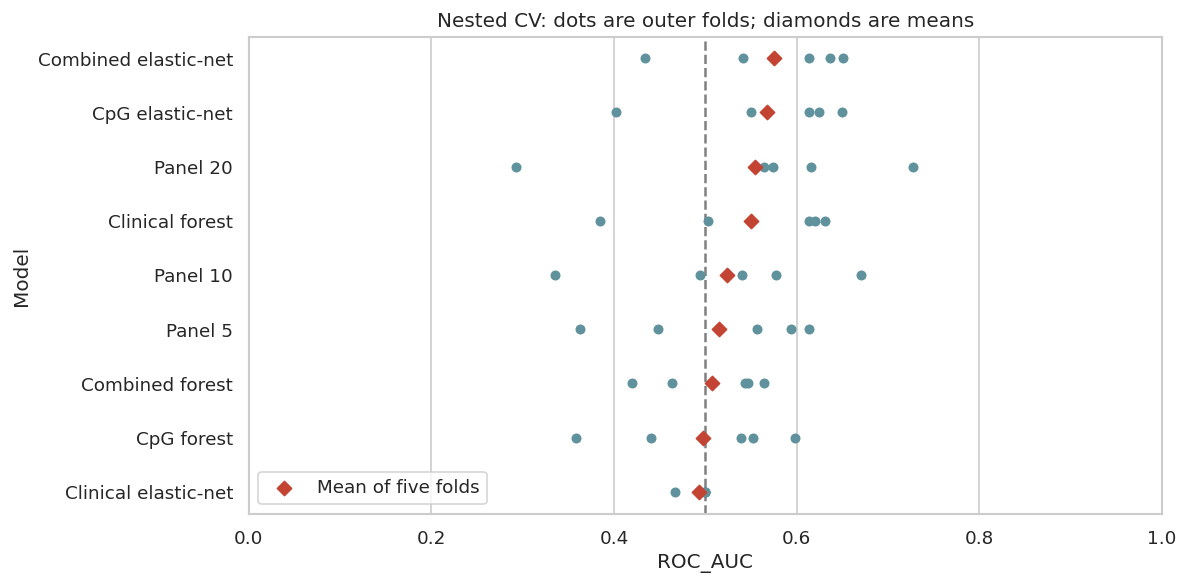

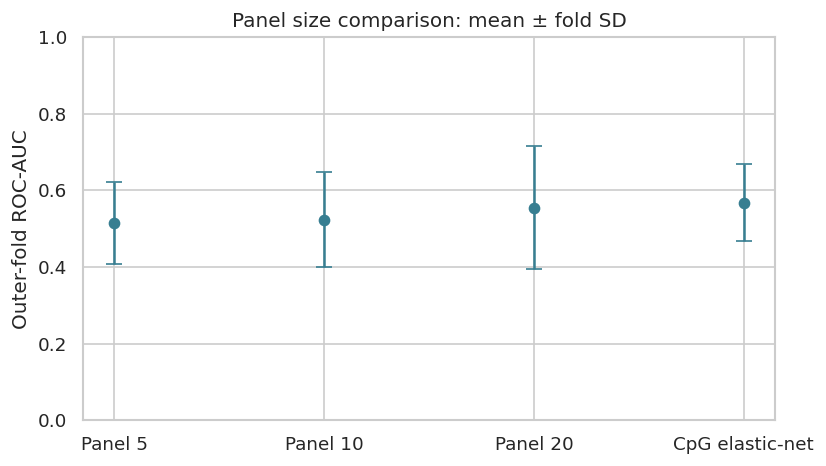

In [7]:
order = summary.index.tolist()
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(data=cv_results, x='ROC_AUC', y='Model', order=order, jitter=False, color='#5f929c', size=6, ax=ax)
ax.scatter(summary.Mean_AUC, np.arange(len(order)), marker='D', color='#c34432', label='Mean of five folds', zorder=4)
ax.axvline(0.5, color='gray', linestyle='--'); ax.set_xlim(0,1)
ax.set_title('Nested CV: dots are outer folds; diamonds are means'); ax.legend(loc='lower left')
finish('05_nested_comparison')
fig, ax = plt.subplots(figsize=(7,4))
for name in ['Panel 5','Panel 10','Panel 20','CpG elastic-net']:
    s = cv_results.loc[cv_results.Model.eq(name),'ROC_AUC']
    ax.errorbar(name,s.mean(),yerr=s.std(),fmt='o',capsize=5,color='#377e91')
ax.set(ylabel='Outer-fold ROC-AUC',title='Panel size comparison: mean ± fold SD',ylim=(0,1))
finish('06_panel_sizes')

## 5. Lock the analysis choices before test evaluation
Choose the smallest CpG panel within 0.02 mean AUC of the best compact panel. This practical rule is fixed above; it does not establish statistical equivalence. Also lock the highest-AUC overall model, the strongest clinical baseline, and the strongest full-CpG model.

All four roles will be reported on the test set as prespecified comparisons. Test results must not be used to select a new winner or revise the panel. The compact panel remains the marker-discovery deliverable even if a different model predicts better.

In [8]:
panel_names = ['Panel 5','Panel 10','Panel 20']
best_panel_auc = summary.loc[panel_names,'Mean_AUC'].max()
selected_panel_name = next(n for n in panel_names if summary.loc[n,'Mean_AUC'] >= best_panel_auc-PANEL_TOLERANCE)
winner_name = summary.index[0]
clinical_name = summary.loc[['Clinical elastic-net','Clinical forest'],'Mean_AUC'].idxmax()
full_name = summary.loc[['CpG elastic-net','CpG forest'],'Mean_AUC'].idxmax()
locked_names = list(dict.fromkeys([selected_panel_name,winner_name,clinical_name,full_name]))
print('Compact panel:', selected_panel_name)
print('Overall model:', winner_name)
print('Clinical comparator:', clinical_name)
print('Full-CpG comparator:', full_name)
final_searches = {name:fit_search(name,X_dev,y_dev,SEED+100) for name in locked_names}
final_models = {name:s.best_estimator_ for name,s in final_searches.items()}
final_panel = final_models[selected_panel_name]
panel_genes = np.array(cpgs)[final_panel.named_steps['select'].get_support()]
print('Locked CpGs:', ', '.join(panel_genes))
print('Locked threshold:', THRESHOLD)

Compact panel: Panel 20
Overall model: Combined elastic-net
Clinical comparator: Clinical forest
Full-CpG comparator: CpG elastic-net
Locked CpGs: cg17975663, cg05044414, cg07628705, cg08335389, cg10931252, cg06520003, cg02257405, cg07753583, cg01617071, cg10376161, cg11593482, cg15157581, cg07502417, cg18113826, cg05254518, cg05645404, cg19171383, cg08529529, cg23084016, cg14781605
Locked threshold: 0.5


## 6. Marker stability and interpretation
Selection frequencies below are fractions of five overlapping outer training sets, not probabilities of biological truth. Panel frequency measures training-only F-score selection; elastic-net frequency measures nonzero coefficients. Elastic-net sign consistency is the larger of positive/negative counts divided by the nonzero count. A value of 1 means all nonzero fits had the same sign.

Final panel coefficients represent a one-development-set-SD increase in the supplied transformed CpG value, conditional on other panel markers. Positive coefficients favor high stage. They do not imply increased raw methylation or causal effects. Descriptive group differences reuse the development data and are not independent validation.

           CpG  Standardized_coefficient  Panel_selection_frequency  Elastic_net_selection_frequency  Elastic_net_sign_consistency  Mean_elastic_net_coefficient  In_final_panel  Development_mean_low  Development_mean_high
0   cg17975663                    -0.271                        1.0                              0.6                           1.0                        -0.191            True                 0.564                  0.444
1   cg05044414                     0.223                        0.6                              0.8                           1.0                         0.350            True                -0.285                 -0.195
2   cg07628705                    -0.023                        0.2                              0.8                           1.0                        -0.106            True                 0.103                 -0.006
3   cg08335389                    -0.090                        0.8                              0.8            

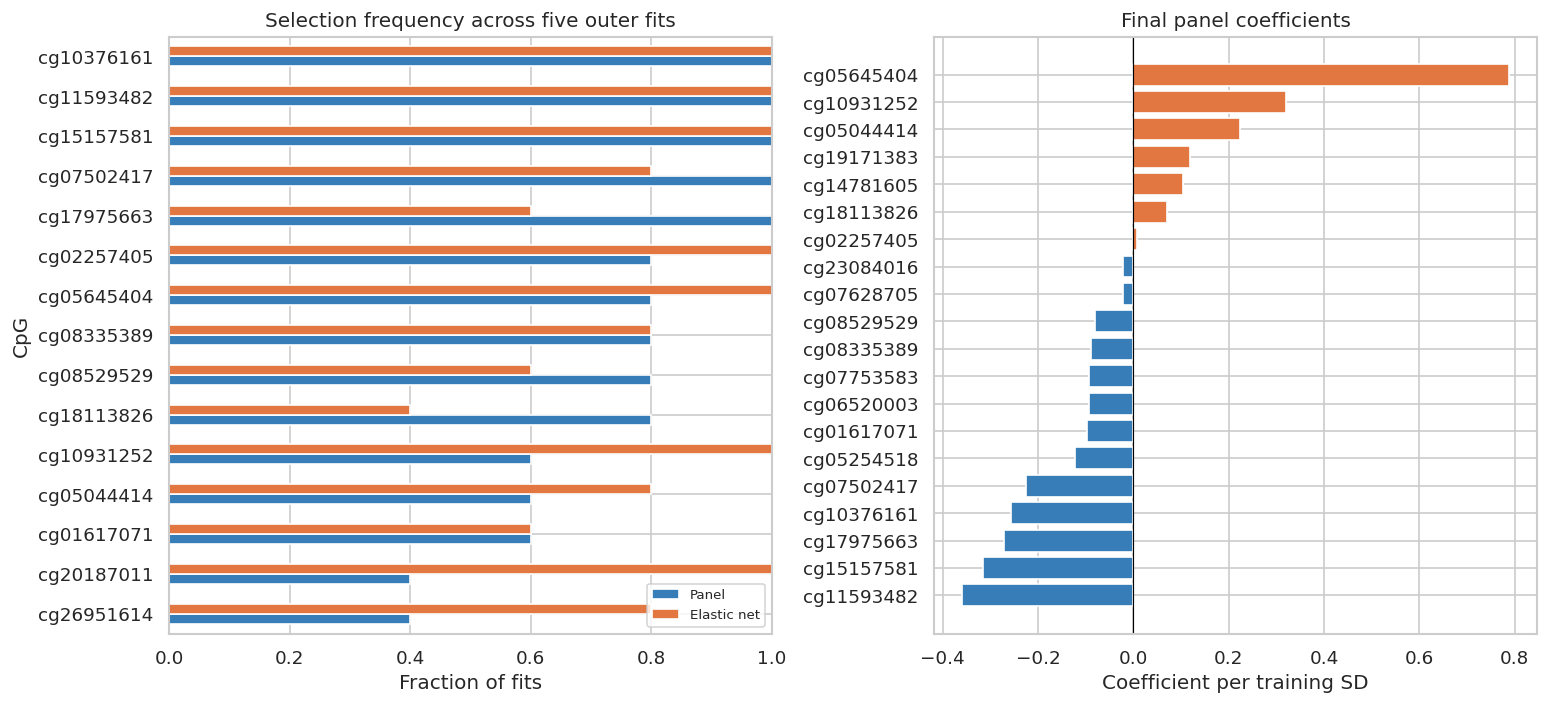

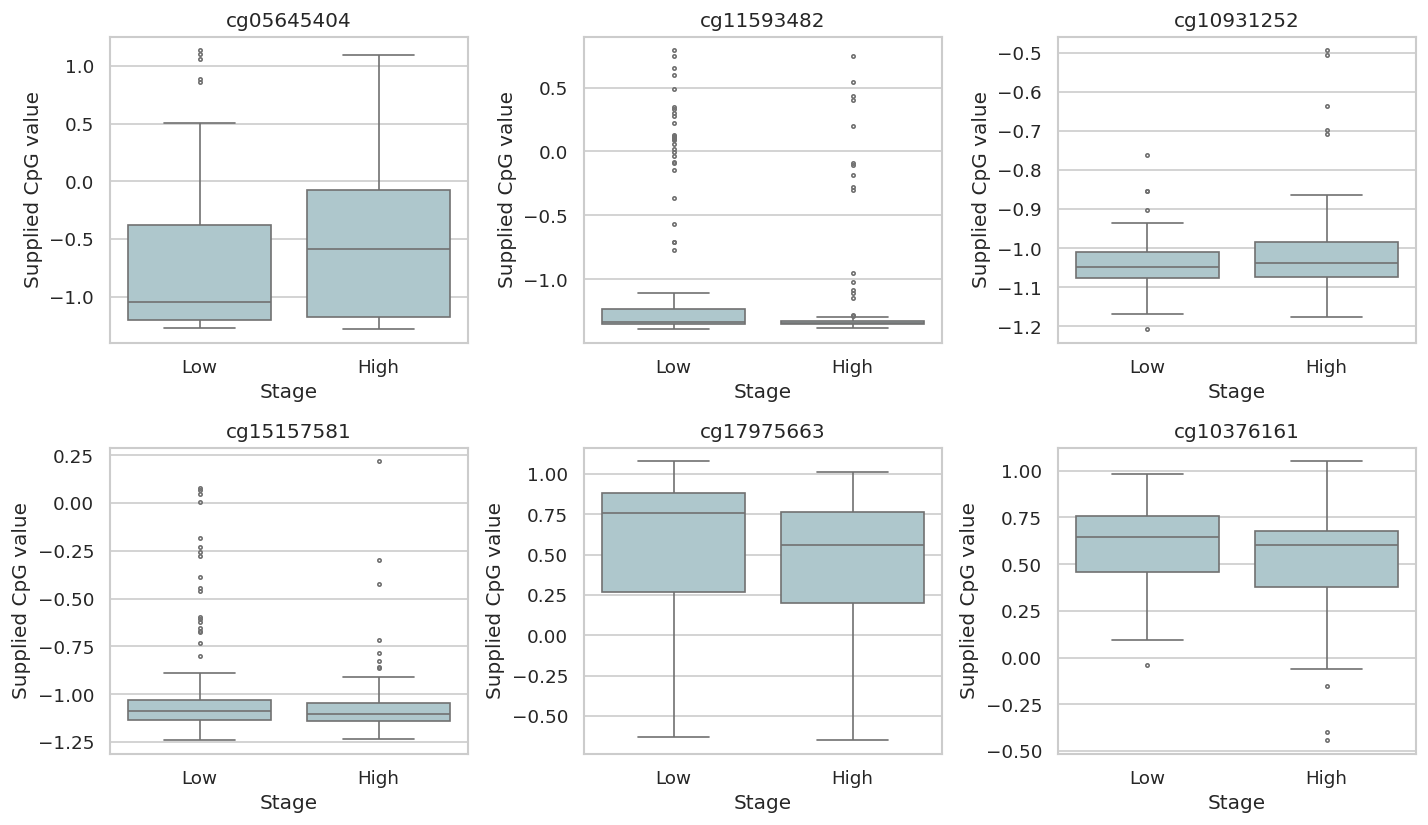

In [9]:
panel_selected = np.array([m.named_steps['select'].get_support() for m in outer_models[selected_panel_name]])
enet_coef = np.array([m.named_steps['model'].coef_[0] for m in outer_models['CpG elastic-net']])
nonzero = np.abs(enet_coef)>1e-8
n_selected = nonzero.sum(axis=0)
consistent = np.divide(np.maximum((enet_coef>1e-8).sum(axis=0),(enet_coef < -1e-8).sum(axis=0)),
                       n_selected,out=np.full(len(cpgs),np.nan),where=n_selected>0)
marker_ranking = pd.DataFrame({'CpG':cpgs, 'Panel_selection_frequency':panel_selected.mean(axis=0),
    'Elastic_net_selection_frequency':nonzero.mean(axis=0), 'Elastic_net_sign_consistency':consistent,
    'Mean_elastic_net_coefficient':enet_coef.mean(axis=0)})
marker_ranking['In_final_panel'] = marker_ranking.CpG.isin(panel_genes)
marker_ranking = marker_ranking.sort_values(['Panel_selection_frequency','Elastic_net_selection_frequency'],ascending=False)
final_panel_table = pd.DataFrame({'CpG':panel_genes,'Standardized_coefficient':final_panel.named_steps['model'].coef_[0]})
final_panel_table = final_panel_table.merge(marker_ranking,on='CpG',validate='one_to_one')
final_panel_table['Development_mean_low'] = [X_dev.loc[y_dev.eq(0),c].mean() for c in final_panel_table.CpG]
final_panel_table['Development_mean_high'] = [X_dev.loc[y_dev.eq(1),c].mean() for c in final_panel_table.CpG]
table(final_panel_table.round(3))
fig, axes = plt.subplots(1,2,figsize=(13,6))
s = marker_ranking.head(15).set_index('CpG')[['Panel_selection_frequency','Elastic_net_selection_frequency']]
s.iloc[::-1].plot.barh(ax=axes[0],color=['#377eb8','#e37742'])
axes[0].set(xlim=(0,1),title='Selection frequency across five outer fits',xlabel='Fraction of fits')
axes[0].legend(['Panel','Elastic net'],fontsize=8)
c = final_panel_table.sort_values('Standardized_coefficient')
axes[1].barh(c.CpG,c.Standardized_coefficient,color=np.where(c.Standardized_coefficient>0,'#e37742','#377eb8'))
axes[1].axvline(0,color='black',linewidth=0.7); axes[1].set(title='Final panel coefficients',xlabel='Coefficient per training SD')
finish('07_marker_stability')

plot_markers = final_panel_table.reindex(final_panel_table.Standardized_coefficient.abs().sort_values(ascending=False).index).CpG.head(6).tolist()
fig, axes = plt.subplots(2,3,figsize=(12,7)); axes=axes.ravel()
for ax, marker in zip(axes,plot_markers):
    sns.boxplot(x=y_dev.map({0:'Low',1:'High'}),y=X_dev[marker],ax=ax,color='#a9cad1',fliersize=2)
    ax.set(title=marker,xlabel='Stage',ylabel='Supplied CpG value')
for ax in axes[len(plot_markers):]: ax.axis('off')
finish('08_marker_distributions')

## Handoff: freeze models and marker choices
This checkpoint stores fitted pipelines, input columns, selected CpGs and tuning settings. Member 3 evaluates these fitted objects without refitting or selecting a new model on test results.

In [10]:
locked = {'versions':versions,'source_hash':development['source_hash'],'split_id':development['split_id'],
          'config':config,'final_models':final_models,'feature_columns':{n:specs[n][0] for n in locked_names},
          'selected_panel_name':selected_panel_name,'winner_name':winner_name,'clinical_name':clinical_name,
          'full_name':full_name,'locked_names':locked_names,'panel_genes':panel_genes,
          'final_panel_table':final_panel_table,'marker_ranking':marker_ranking,
          'cv_results':cv_results,'summary':summary,
          'best_parameters':{n:s.best_params_ for n,s in final_searches.items()}}
joblib.dump(locked,CHECKPOINTS/'locked_models.joblib')
for name, frame in {'nested_cv_folds':cv_results,'nested_cv_summary':summary,
                    'marker_ranking':marker_ranking,'selected_panel':final_panel_table}.items():
    frame.to_csv(OUT/(name+'.csv'),index=name=='nested_cv_summary')
print('Send checkpoints/locked_models.joblib to Member 3.')
print('Locked panel:',selected_panel_name,'| Threshold:',THRESHOLD)

Send checkpoints/locked_models.joblib to Member 3.
Locked panel: Panel 20 | Threshold: 0.5


## References and interpretation guide
- Input data: user-supplied `Xsurv.csv`; starting specification: `project_Xsurv.ipynb`. The original notebook cites [Efficient gradient boosting for prognostic biomarker discovery](https://doi.org/10.1093/bioinformatics/btab869). This notebook analyzes the supplied stage outcome only; it does not reproduce that survival study.
- [scikit-learn: common pitfalls and data leakage](https://scikit-learn.org/stable/common_pitfalls.html): fit preprocessing and feature selection using training partitions only.
- [scikit-learn: nested versus non-nested cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html): separate tuning from outer-fold assessment.

**Reading the figures:** PCA shows major variation, not validated classification. Fold dots show sensitivity to the training split. Selection frequency shows reproducibility within these development folds. Coefficient signs describe the fitted conditional association. ROC/precision–recall curves evaluate the locked models on held-out patients. Bootstrap intervals describe uncertainty in those test patients, conditional on the trained models.

**Before a scientific claim:** verify independent patients, original filtering and normalization, AGE/SEX metadata, assay annotations and external replication. A compact panel that performs poorly is still an informative result; do not relabel it as a validated biomarker panel.

## Download your results and handoffs
In Colab, this cell downloads your results archive and any checkpoints generated by your part. Allow multiple downloads if your browser asks. You can also download individual files through Colab’s Files panel.

In [11]:
# Optional: run this cell to download outputs before ending your Colab session.
import shutil
archive = shutil.make_archive('member_2_results', 'zip', str(OUT))
if IN_COLAB:
    colab_files.download(archive)
    for filename in ['locked_models.joblib']:
        colab_files.download(str(CHECKPOINTS/filename))
else:
    print('Results archive:', archive)


Results archive: /workspace/scratch/f1a0843b0c79/group_split/member_2_results.zip
